#### Decsion tree ####

In [376]:
# import lbraries:
import pandas as pd

In [377]:
# reading dataset or csv:
dataset = pd.read_csv('50_Startups.csv')
dataset.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [378]:
# convert categorical column:
dataset = pd.get_dummies(dataset,drop_first=True)
dataset.head()

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,False,True
1,162597.70,151377.59,443898.53,191792.06,False,False
2,153441.51,101145.55,407934.54,191050.39,True,False
3,144372.41,118671.85,383199.62,182901.99,False,True
4,142107.34,91391.77,366168.42,166187.94,True,False


In [379]:
# Split input and output columns:
dataset.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='object')

In [380]:
independent = dataset[['R&D Spend', 'Administration', 'Marketing Spend',
       'State_Florida', 'State_New York']]

In [381]:
dependent = dataset[['Profit']]

In [382]:
# Split test and train data:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(independent,dependent,test_size=0.30,random_state=0)

In [383]:
# Standardisation:if need

In [384]:
# model selection:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(max_depth=10,min_samples_leaf=5,ccp_alpha=0.001,random_state=42)
# train the model:
regressor = regressor.fit(x_train,y_train)
regressor

DecisionTreeRegressor(ccp_alpha=0.001, max_depth=10, min_samples_leaf=5,
                      random_state=42)

In [385]:
# test the train model: 
from sklearn.metrics import r2_score

y_train_pred = regressor.predict(x_train)
train_r2 = r2_score(y_train, y_train_pred)
train_r2

0.9264722695484351

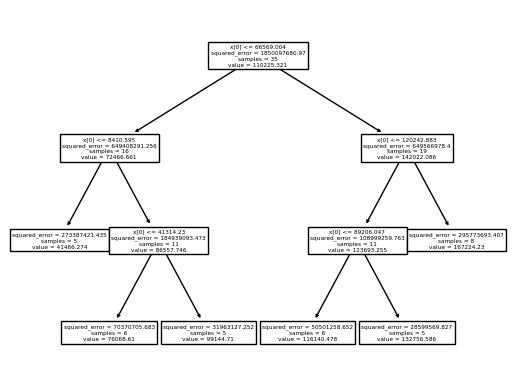

In [386]:
# Tree:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(regressor)
plt.show()

In [387]:
# Test the model:
y_pred = regressor.predict(x_test)
y_pred

array([ 99144.71      , 132756.586     , 132756.586     ,  76068.61      ,
       167224.23      , 116140.47833333,  76068.61      ,  99144.71      ,
       116140.47833333, 167224.23      ,  99144.71      ,  99144.71      ,
       116140.47833333,  99144.71      , 132756.586     ])

In [388]:
# Evaluate the model: here i am gong to use r2:
from sklearn.metrics import r2_score
test_r2 = r2_score(y_test,y_pred)
test_r2 

0.9112052431238806

In [389]:
print("Training R²:", train_r2)
print("Test R²:", test_r2)

Training R²: 0.9264722695484351
Test R²: 0.9112052431238806


In [390]:
# my understanding:0.6-0.7 means underfit,0.8 - 0.9 means moderate fit, above 0.9 means acceptable :
# tuning parameter:
# 1️.max_depth ↓
# 2️.min_samples_leaf ↑
# 3️. ccp_alpha ↑

'''# Base model.max_depth=None,min_samples_leaf=1,ccp_alpha=0.0----> Training R²: 1.0,Test R²: 0.917
 m1.max_depth=10,min_samples_leaf=1,ccp_alpha=0.0 ----> Training R²: 1.0,Test R²: 0.9122517547509665
 m2.max_depth=10,min_samples_leaf=5,ccp_alpha=0.0 ----> Training R²: 0.9264722695484351,Test R²: 0.9112052431238806 
 m3.max_depth=None,min_samples_leaf=1,ccp_alpha=0.001-> Training R²: 1.0,Test R²: 0.9122517547509665
 m4.max_depth=10,min_samples_leaf=5,ccp_alpha=0.001--->Training R²: 0.9264722695484351,Test R²: 0.9112052431238806'''
'''Models m2 and m4 show better generalization because the training and test R² values are close, 
indicating reduced overfitting. Although their test R² is slightly lower than the fully grown tree,
they are more stable and less complex.'''

1.Base model:
    Training R² = 1.0
    Test R² = 0.917
    Gap = 0.083
 This means:
    Tree memorized training data
    High variance
    Performance may drop badly on new unseen data
2.m2 / m4:
    Lower training R²-0.926
    test R²-0.911
    Very small gap

 More stable, robust, trustworthy..

In [392]:
# final model name or file creation:
filename= 'finalized_model_Decision_tree_regression.sav'
# dump the model in file:
import pickle
pickle.dump(regressor,open(filename,'wb'))

In [393]:
# load the model:
loaded_model = pickle.load(open('finalized_model_Decision_tree_regression.sav','rb'))
loaded_model

DecisionTreeRegressor(ccp_alpha=0.001, max_depth=10, min_samples_leaf=5,
                      random_state=42)

In [394]:
# model prediction:
result = loaded_model.predict([[1234,345,4565,1,0]])
result

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([41466.274])